# Phase-Folded Kinematic Margin

Phase-folds the kinematic margin against position-since-last-skip: each pair `i` is reindexed by `p = i - (largest skip index <= i)`, collapsing the skip-locked sawtooth onto a single mean curve per segment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

import sys
sys.path.insert(0, '..')

from ksb.simulation.ksb_simulation import KSBSimulation
from ksb.visualization.segment_event_plots import plot_phase_folded_margin

## Run simulation

In [2]:
config_path = Path("../configs/system/default.yaml")
with open(config_path) as f:
    cfg = yaml.safe_load(f)

print(f"Config: batch={cfg['batch']}, n_buffer_seg={cfg['n_buffer_seg']}")
print(f"Solver: {cfg.get('solver', 'scurve')}")

sim = KSBSimulation(cfg=cfg)
result = sim.run(seed=42)

margin = result.segment_sync_response.kinematic_margin
skips = result.skip_indices
n_segments = cfg['n_buffer_seg']

print(f"margin shape: {margin.shape}")
print(f"skip_indices: {skips}")

Config: batch=100, n_buffer_seg=7
Solver: ruckig
margin shape: (99, 7)
skip_indices: [ 0  1  2  3  4  5  6  8  9 10 12 13 14 16 18 19 20 23 25 26 28 29 30 31
 32 33 34 35 36 37 39 40 42 44 45 46 47 48 49 50 56 57 58 59 60 62 64 65
 66 67 68 74 75 76 77 78 79 81 83 84 85 88 89 90 91 92 93 94]


## Phase-folded margin — first segments

`plot_phase_folded_margin` groups pairs by phase (pairs elapsed since the most recent skip) and plots the mean margin per phase, shaded by `mean ± std`. The horizontal line at `M = 0` is the feasibility boundary.

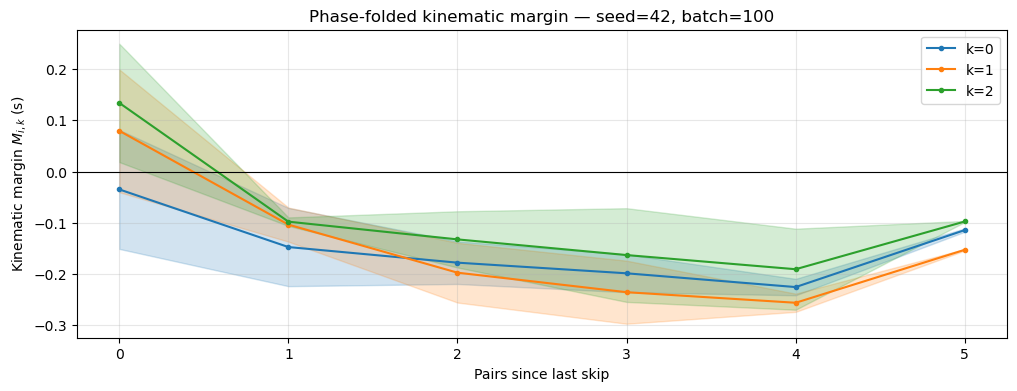

In [3]:
fig, ax = plot_phase_folded_margin(
    margin, skips,
    segments=range(min(3, n_segments)),
    title=f"Phase-folded kinematic margin — seed=42, batch={cfg['batch']}",
)
ax.grid(alpha=0.3)
plt.show()

## Phase-folded margin — last segments, IQR band

Same fold, later segments, with `band="iqr"` (25th-75th percentile) instead of `mean ± std`.

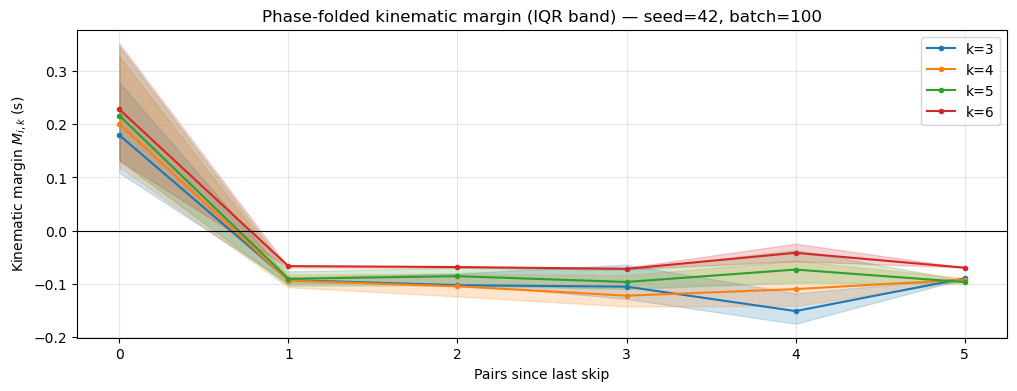

In [4]:
fig, ax = plot_phase_folded_margin(
    margin, skips,
    segments=range(max(0, n_segments - 4), n_segments),
    band="iqr",
    title=f"Phase-folded kinematic margin (IQR band) — seed=42, batch={cfg['batch']}",
)
ax.grid(alpha=0.3)
plt.show()